In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime,timedelta

In [18]:
nifty_1 = r"C:\Users\hp\Downloads\NIFTY 50-09-03-2024-to-08-03-2025.csv"
nifty_2 = r"C:\Users\hp\Downloads\NIFTY 50-9-03-2025-to-9-03-2026.csv"
year_1 = pd.read_csv(nifty_1)
year_2 = pd.read_csv(nifty_2)
year_1.columns = year_1.columns.str.strip()
year_2.columns = year_2.columns.str.strip()

In [22]:
year_1['Date'] = pd.to_datetime(year_1['Date'], dayfirst=True)
year_2['Date'] = pd.to_datetime(year_2['Date'], dayfirst=True)
df = pd.concat([year_1, year_2], ignore_index=True)
df = df.sort_values('Date').reset_index(drop=True)
df

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2024-03-11,22517.50,22526.60,22307.25,22332.65,277897373,27222.37
1,2024-03-12,22334.45,22452.55,22256.00,22335.70,299201167,29781.12
2,2024-03-13,22432.20,22446.75,21905.65,21997.70,493341697,40109.23
3,2024-03-14,21982.55,22204.60,21917.50,22146.65,426742460,37348.30
4,2024-03-15,22064.85,22120.90,21931.70,22023.35,661460455,60260.88
...,...,...,...,...,...,...,...
490,2026-03-02,24659.25,24989.35,24603.50,24865.70,519228821,41306.37
491,2026-03-04,24388.80,24602.45,24305.40,24480.50,598993881,47700.19
492,2026-03-05,24615.95,24854.20,24529.40,24765.90,504339053,40011.88
493,2026-03-06,24656.40,24700.80,24415.75,24450.45,433408256,35453.32


In [23]:
df.dropna(inplace=True)
df

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2024-03-11,22517.50,22526.60,22307.25,22332.65,277897373,27222.37
1,2024-03-12,22334.45,22452.55,22256.00,22335.70,299201167,29781.12
2,2024-03-13,22432.20,22446.75,21905.65,21997.70,493341697,40109.23
3,2024-03-14,21982.55,22204.60,21917.50,22146.65,426742460,37348.30
4,2024-03-15,22064.85,22120.90,21931.70,22023.35,661460455,60260.88
...,...,...,...,...,...,...,...
490,2026-03-02,24659.25,24989.35,24603.50,24865.70,519228821,41306.37
491,2026-03-04,24388.80,24602.45,24305.40,24480.50,598993881,47700.19
492,2026-03-05,24615.95,24854.20,24529.40,24765.90,504339053,40011.88
493,2026-03-06,24656.40,24700.80,24415.75,24450.45,433408256,35453.32


In [26]:
returns = df['Close'].pct_change().dropna()
print(returns)

1      0.000137
2     -0.015133
3      0.006771
4     -0.005567
5      0.001469
         ...   
490   -0.012429
491   -0.015491
492    0.011658
493   -0.012737
494   -0.017276
Name: Close, Length: 494, dtype: float64


In [28]:
cum_returns = np.cumprod(1+returns) - 1
print(cum_returns)

1      0.000137
2     -0.014998
3     -0.008329
4     -0.013850
5     -0.012401
         ...   
490    0.113424
491    0.096175
492    0.108955
493    0.094830
494    0.075916
Name: Close, Length: 494, dtype: float64


In [30]:
price_path = 100 * np.cumprod(1+returns)
print(price_path)

1      100.013657
2       98.500178
3       99.167139
4       98.615032
5       98.759887
          ...    
490    111.342362
491    109.617533
492    110.895483
493    109.482977
494    107.591576
Name: Close, Length: 494, dtype: float64


In [31]:
total_cum_return = np.prod(1 + returns) - 1
print(total_cum_return)

0.07591575563133213


In [34]:
df.mean()

Date               2025-03-10 12:33:27.272727296
Open                                24387.254141
High                                24493.155455
Low                                 24262.067677
Close                                24377.78101
Shares Traded                   322966291.965657
Turnover (₹ Cr)                     30259.975657
dtype: object

In [35]:
df.std()

Date               210 days 01:43:49.276323340
Open                               1174.704968
High                               1162.443086
Low                                1184.457357
Close                              1170.976551
Shares Traded                 106867151.745689
Turnover (₹ Cr)                    9817.636385
dtype: object

In [37]:
#simple sharpe ratio
mu_daily = returns.mean()
sigma_daily = returns.std()
sharpe_daily = mu_daily/sigma_daily
print(sharpe_daily)

0.022024668161245986


In [38]:
sharpe_annual = sharpe_daily * np.sqrt(252)
print(sharpe_annual)

0.3496307679802747


In [41]:
#annualized Sharpe ratio
periods_per_year = 252
rf_annual = 0.015
annual_ret = (1+returns).prod() ** (periods_per_year/len(returns)) - 1 #annualized returns
annual_vol = returns.std() * np.sqrt(periods_per_year) #annualized volatility
annualized_sharpe = (annual_ret - rf_annual)/annual_vol
print(annualized_sharpe)

0.1751279909968017


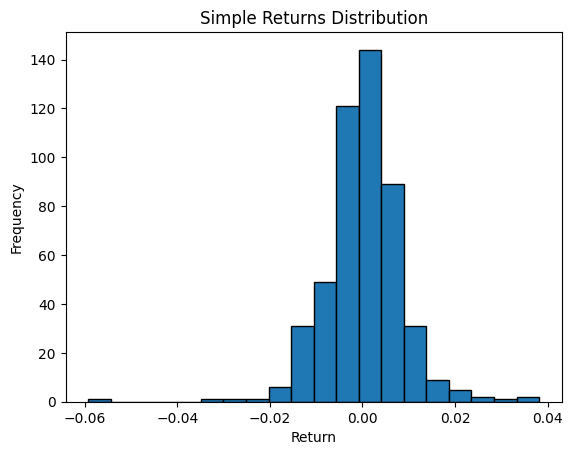

In [45]:
plt.title('Simple Returns Distribution')
plt.hist(returns, bins=20, edgecolor="black")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

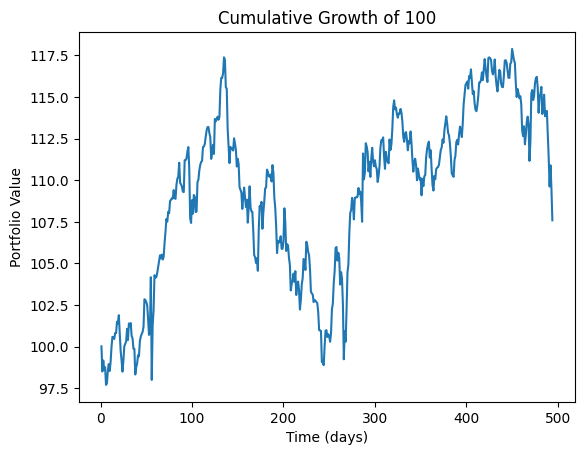

In [47]:
plt.title("Cumulative Growth of 100")
plt.plot(price_path)
plt.xlabel("Time (days)")
plt.ylabel("Portfolio Value")
plt.show()